Using device: cpu
Loading model from: /content/best_spine_unet.pth
✓ Loaded model weights
✓ Model ready on cpu


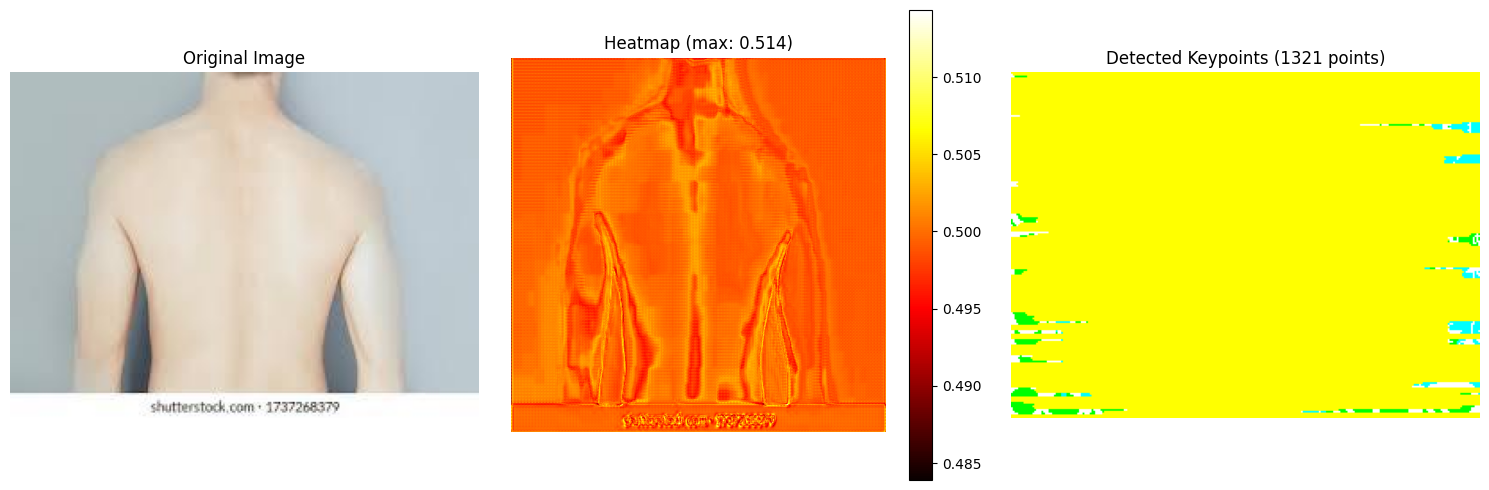

✓ Saved result to: result_keypoints.jpg

Detected keypoints:
Point 1: x=192, y=178, confidence=0.514
Point 2: x=116, y=185, confidence=0.514
Point 3: x=261, y=0, confidence=0.512
Point 4: x=182, y=187, confidence=0.512
Point 5: x=117, y=188, confidence=0.512
Point 6: x=145, y=189, confidence=0.511
Point 7: x=168, y=0, confidence=0.511
Point 8: x=178, y=0, confidence=0.511
Point 9: x=186, y=0, confidence=0.511
Point 10: x=207, y=0, confidence=0.511
Point 11: x=258, y=0, confidence=0.511
Point 12: x=233, y=0, confidence=0.511
Point 13: x=91, y=185, confidence=0.511
Point 14: x=199, y=0, confidence=0.511
Point 15: x=239, y=0, confidence=0.511
Point 16: x=248, y=0, confidence=0.511
Point 17: x=194, y=0, confidence=0.511
Point 18: x=244, y=0, confidence=0.511
Point 19: x=217, y=0, confidence=0.511
Point 20: x=221, y=0, confidence=0.511
Point 21: x=225, y=0, confidence=0.511
Point 22: x=213, y=0, confidence=0.511
Point 23: x=161, y=183, confidence=0.511
Point 24: x=149, y=185, confidence=0.5

In [3]:


import torch
import torch.nn as nn
import cv2
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from scipy.ndimage import maximum_filter

# U-Net Model (giống như lúc train)
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.conv(x)

class UNet(nn.Module):
    def __init__(self, in_ch=3, out_ch=1):
        super().__init__()

        # Encoder
        self.enc1 = DoubleConv(in_ch, 64)
        self.pool1 = nn.MaxPool2d(2)
        self.enc2 = DoubleConv(64, 128)
        self.pool2 = nn.MaxPool2d(2)
        self.enc3 = DoubleConv(128, 256)
        self.pool3 = nn.MaxPool2d(2)
        self.enc4 = DoubleConv(256, 512)
        self.pool4 = nn.MaxPool2d(2)

        # Bottleneck
        self.bottleneck = DoubleConv(512, 1024)

        # Decoder
        self.up1 = nn.ConvTranspose2d(1024, 512, 2, stride=2)
        self.dec1 = DoubleConv(1024, 512)
        self.up2 = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.dec2 = DoubleConv(512, 256)
        self.up3 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec3 = DoubleConv(256, 128)
        self.up4 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec4 = DoubleConv(128, 64)

        self.out = nn.Conv2d(64, out_ch, 1)

    def forward(self, x):
        # Encoder
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool1(e1))
        e3 = self.enc3(self.pool2(e2))
        e4 = self.enc4(self.pool3(e3))

        # Bottleneck
        b = self.bottleneck(self.pool4(e4))

        # Decoder with skip connections
        d1 = self.dec1(torch.cat([self.up1(b), e4], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d1), e3], dim=1))
        d3 = self.dec3(torch.cat([self.up3(d2), e2], dim=1))
        d4 = self.dec4(torch.cat([self.up4(d3), e1], dim=1))

        return self.out(d4)


class SpineKeypointPredictor:
    def __init__(self, model_path, img_size=512, device=None):
        """
        Khởi tạo predictor

        Args:
            model_path: đường dẫn tới file .pth
            img_size: kích thước ảnh input
            device: 'cuda' hoặc 'cpu' (None = auto detect)
        """
        self.img_size = img_size

        # Auto detect device
        if device is None:
            self.device = 'cuda' if torch.cuda.is_available() else 'cpu'
        else:
            self.device = device

        print(f"Using device: {self.device}")

        # Load model
        print(f"Loading model from: {model_path}")
        self.model = UNet(in_ch=3, out_ch=1)

        # Load weights với map_location để tránh lỗi CUDA
        checkpoint = torch.load(model_path, map_location=torch.device(self.device))

        # Xử lý cả 2 trường hợp: dict hoặc state_dict trực tiếp
        if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint:
            self.model.load_state_dict(checkpoint['model_state_dict'])
            print(f"✓ Loaded checkpoint from epoch {checkpoint.get('epoch', 'unknown')}")
        else:
            self.model.load_state_dict(checkpoint)
            print("✓ Loaded model weights")

        self.model.to(self.device)
        self.model.eval()
        print(f"✓ Model ready on {self.device}")

    def preprocess_image(self, img_path):
        """Tiền xử lý ảnh"""
        # Đọc ảnh
        img = cv2.imread(str(img_path))
        if img is None:
            raise ValueError(f"Cannot load image: {img_path}")

        img_bgr = img.copy()
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # Lưu kích thước gốc
        orig_h, orig_w = img.shape[:2]

        # Resize
        img_resized = cv2.resize(img, (self.img_size, self.img_size))

        # Normalize (giống lúc train)
        img_normalized = img_resized.astype(np.float32) / 255.0
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        img_normalized = (img_normalized - mean) / std

        # Convert to tensor
        img_tensor = torch.from_numpy(img_normalized.transpose(2, 0, 1)).float()
        img_tensor = img_tensor.unsqueeze(0)  # Add batch dimension

        return img_tensor, img_bgr, (orig_h, orig_w)

    def extract_keypoints(self, heatmap, threshold=0.3, min_distance=10):
        """
        Trích xuất tọa độ keypoints từ heatmap

        Args:
            heatmap: numpy array (H, W)
            threshold: ngưỡng để detect peak
            min_distance: khoảng cách tối thiểu giữa các peak

        Returns:
            List of (x, y, confidence)
        """
        # Áp dụng non-maximum suppression
        local_max = maximum_filter(heatmap, size=min_distance) == heatmap

        # Tìm các điểm có giá trị > threshold
        detected = (heatmap > threshold) & local_max

        # Lấy tọa độ
        y_coords, x_coords = np.where(detected)
        confidences = heatmap[y_coords, x_coords]

        # Sắp xếp theo confidence
        keypoints = []
        for x, y, conf in zip(x_coords, y_coords, confidences):
            keypoints.append((int(x), int(y), float(conf)))

        keypoints.sort(key=lambda k: k[2], reverse=True)

        return keypoints

    def predict(self, img_path, threshold=0.3, min_distance=10):
        """
        Predict keypoints từ ảnh

        Args:
            img_path: đường dẫn ảnh
            threshold: ngưỡng detect
            min_distance: khoảng cách min giữa các điểm

        Returns:
            keypoints: list of (x, y, confidence)
            img_original: ảnh gốc
            heatmap: heatmap output
        """
        # Preprocess
        img_tensor, img_original, (orig_h, orig_w) = self.preprocess_image(img_path)

        # Predict
        with torch.no_grad():
            img_tensor = img_tensor.to(self.device)
            output = self.model(img_tensor)
            heatmap = torch.sigmoid(output).cpu().numpy()[0, 0]

        # Extract keypoints
        keypoints = self.extract_keypoints(heatmap, threshold, min_distance)

        # Scale keypoints về kích thước ảnh gốc
        scale_x = orig_w / self.img_size
        scale_y = orig_h / self.img_size

        keypoints_scaled = [
            (int(x * scale_x), int(y * scale_y), conf)
            for x, y, conf in keypoints
        ]

        return keypoints_scaled, img_original, heatmap

    def visualize(self, img_path, save_path=None, threshold=0.3,
                  min_distance=10, show=True):
        """
        Vẽ keypoints lên ảnh

        Args:
            img_path: đường dẫn ảnh input
            save_path: đường dẫn lưu ảnh output
            threshold: ngưỡng detect
            min_distance: khoảng cách min
            show: hiển thị ảnh
        """
        # Predict
        keypoints, img_original, heatmap = self.predict(
            img_path, threshold, min_distance
        )

        # Vẽ keypoints lên ảnh
        img_result = img_original.copy()

        for i, (x, y, conf) in enumerate(keypoints):
            # Vẽ điểm
            cv2.circle(img_result, (x, y), 8, (0, 255, 0), -1)

            # Vẽ viền
            cv2.circle(img_result, (x, y), 10, (255, 255, 255), 2)

            # Vẽ số thứ tự
            cv2.putText(img_result, str(i+1), (x+15, y),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 0), 2)

            # Vẽ confidence
            conf_text = f"{conf:.2f}"
            cv2.putText(img_result, conf_text, (x+15, y+20),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1)

        # Vẽ đường nối giữa các điểm (cột sống)
        if len(keypoints) > 1:
            # Sắp xếp theo y (từ trên xuống dưới)
            keypoints_sorted = sorted(keypoints, key=lambda k: k[1])
            for i in range(len(keypoints_sorted) - 1):
                pt1 = (keypoints_sorted[i][0], keypoints_sorted[i][1])
                pt2 = (keypoints_sorted[i+1][0], keypoints_sorted[i+1][1])
                cv2.line(img_result, pt1, pt2, (0, 255, 255), 2)

        # Hiển thị
        if show:
            plt.figure(figsize=(15, 5))

            # Ảnh gốc
            plt.subplot(1, 3, 1)
            plt.imshow(cv2.cvtColor(img_original, cv2.COLOR_BGR2RGB))
            plt.title('Original Image')
            plt.axis('off')

            # Heatmap
            plt.subplot(1, 3, 2)
            plt.imshow(heatmap, cmap='hot')
            plt.title(f'Heatmap (max: {heatmap.max():.3f})')
            plt.colorbar()
            plt.axis('off')

            # Kết quả
            plt.subplot(1, 3, 3)
            plt.imshow(cv2.cvtColor(img_result, cv2.COLOR_BGR2RGB))
            plt.title(f'Detected Keypoints ({len(keypoints)} points)')
            plt.axis('off')

            plt.tight_layout()
            plt.show()

        # Lưu ảnh
        if save_path:
            cv2.imwrite(save_path, img_result)
            print(f"✓ Saved result to: {save_path}")

        return img_result, keypoints


# ===== SỬ DỤNG =====
if __name__ == '__main__':
    # 1. Khởi tạo predictor (tự động detect CPU/GPU)
    predictor = SpineKeypointPredictor(
        model_path='/content/best_spine_unet.pth',  # Đường dẫn model đã train
        img_size=512,
        device=None  # None = auto detect, hoặc chỉ định 'cpu' hoặc 'cuda'
    )

    # 2. Predict một ảnh
    img_path = '/content/drive/MyDrive/scoliosis.v1i.voc/test/IMG_1504_JPG.rf.72b52ae6156c86933ab5b6763b70ab99.jpg'  # Đường dẫn ảnh cần test

    result_img, keypoints = predictor.visualize(
        img_path=img_path,
        save_path='result_keypoints.jpg',
        threshold=0.3,      # Điều chỉnh ngưỡng detect
        min_distance=10,    # Khoảng cách min giữa các điểm
        show=True           # Hiển thị kết quả
    )

    # 3. In ra tọa độ các điểm
    print("\nDetected keypoints:")
    for i, (x, y, conf) in enumerate(keypoints):
        print(f"Point {i+1}: x={x}, y={y}, confidence={conf:.3f}")

    # 4. Predict nhiều ảnh
    print("\n" + "="*60)
    print("Processing multiple images...")

    test_images = ['/content/drive/MyDrive/scoliosis.v1i.voc/test/IMG_1318-1-_JPG.rf.26a718b17ea7aa8e7dc803e9f08574c2.jpg']

    for img_path in test_images:
        if Path(img_path).exists():
            output_path = f"result_{Path(img_path).stem}.jpg"
            result_img, keypoints = predictor.visualize(
                img_path=img_path,
                save_path=output_path,
                threshold=0.3,
                show=False  # Không hiển thị, chỉ lưu
            )
            print(f"✓ Processed {img_path}: {len(keypoints)} keypoints detected")
        else:
            print(f"✗ File not found: {img_path}")

In [1]:
# UNET with COCO
!pip install torch torchvision opencv-python albumentations pillow

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import cv2
import json
from pathlib import Path
from PIL import Image
import albumentations as A
from albumentations.pytorch import ToTensorV2

# U-Net Model
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.conv(x)

class UNet(nn.Module):
    def __init__(self, in_ch=3, out_ch=1):
        super().__init__()

        # Encoder
        self.enc1 = DoubleConv(in_ch, 64)
        self.pool1 = nn.MaxPool2d(2)
        self.enc2 = DoubleConv(64, 128)
        self.pool2 = nn.MaxPool2d(2)
        self.enc3 = DoubleConv(128, 256)
        self.pool3 = nn.MaxPool2d(2)
        self.enc4 = DoubleConv(256, 512)
        self.pool4 = nn.MaxPool2d(2)

        # Bottleneck
        self.bottleneck = DoubleConv(512, 1024)

        # Decoder
        self.up1 = nn.ConvTranspose2d(1024, 512, 2, stride=2)
        self.dec1 = DoubleConv(1024, 512)
        self.up2 = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.dec2 = DoubleConv(512, 256)
        self.up3 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec3 = DoubleConv(256, 128)
        self.up4 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec4 = DoubleConv(128, 64)

        self.out = nn.Conv2d(64, out_ch, 1)

    def forward(self, x):
        # Encoder
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool1(e1))
        e3 = self.enc3(self.pool2(e2))
        e4 = self.enc4(self.pool3(e3))

        # Bottleneck
        b = self.bottleneck(self.pool4(e4))

        # Decoder with skip connections
        d1 = self.dec1(torch.cat([self.up1(b), e4], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d1), e3], dim=1))
        d3 = self.dec3(torch.cat([self.up3(d2), e2], dim=1))
        d4 = self.dec4(torch.cat([self.up4(d3), e1], dim=1))

        return self.out(d4)

# COCO Dataset Loader
class SpineKeypointDataset(Dataset):
    def __init__(self, img_dir, anno_file, img_size=512, sigma=5, transform=None):
        self.img_dir = Path(img_dir)
        self.img_size = img_size
        self.sigma = sigma
        self.transform = transform

        # Kiểm tra đường dẫn tồn tại
        if not self.img_dir.exists():
            raise FileNotFoundError(f"Image directory not found: {self.img_dir.absolute()}")

        if not Path(anno_file).exists():
            raise FileNotFoundError(f"Annotation file not found: {Path(anno_file).absolute()}")

        # Load COCO annotations
        print(f"Loading annotations from: {anno_file}")
        with open(anno_file, 'r') as f:
            self.coco = json.load(f)

        self.images = {img['id']: img for img in self.coco['images']}
        self.annotations = {}

        for anno in self.coco['annotations']:
            img_id = anno['image_id']
            if img_id not in self.annotations:
                self.annotations[img_id] = []
            self.annotations[img_id].append(anno)

        self.img_ids = list(self.annotations.keys())

        # Verify images exist
        print(f"Checking if images exist...")
        missing_images = []
        for img_id in self.img_ids[:min(10, len(self.img_ids))]:  # Check first 10
            img_info = self.images[img_id]
            img_path = self.img_dir / img_info['file_name']
            if not img_path.exists():
                missing_images.append(str(img_path))

        if missing_images:
            print(f"\nWARNING: Some images not found:")
            for path in missing_images[:5]:
                print(f"  - {path}")
            print(f"\nPlease check:")
            print(f"  1. img_dir is correct: {self.img_dir.absolute()}")
            print(f"  2. file_name in JSON matches actual files")

    def __len__(self):
        return len(self.img_ids)

    def create_heatmap(self, keypoints, img_h, img_w):
        """Tạo heatmap từ keypoints"""
        heatmap = np.zeros((img_h, img_w), dtype=np.float32)

        for i in range(0, len(keypoints), 3):
            x, y, v = keypoints[i], keypoints[i+1], keypoints[i+2]

            if v > 0:  # visibility flag
                x = int(x * img_w)
                y = int(y * img_h)

                # Tạo Gaussian heatmap
                if 0 <= x < img_w and 0 <= y < img_h:
                    xx, yy = np.meshgrid(np.arange(img_w), np.arange(img_h))
                    heatmap += np.exp(-((xx - x)**2 + (yy - y)**2) / (2 * self.sigma**2))

        # Normalize
        if heatmap.max() > 0:
            heatmap = heatmap / heatmap.max()

        return heatmap

    def __getitem__(self, idx):
        img_id = self.img_ids[idx]
        img_info = self.images[img_id]
        img_path = self.img_dir / img_info['file_name']

        # Load image with detailed error checking
        img = cv2.imread(str(img_path))

        if img is None:
            raise FileNotFoundError(
                f"\n{'='*60}\n"
                f"ERROR: Cannot load image!\n"
                f"{'='*60}\n"
                f"File path: {img_path}\n"
                f"Absolute path: {img_path.absolute()}\n"
                f"File exists: {img_path.exists()}\n"
                f"img_dir: {self.img_dir.absolute()}\n"
                f"file_name from JSON: {img_info['file_name']}\n"
                f"\nPlease verify:\n"
                f"  1. The image file exists at the path above\n"
                f"  2. The file is a valid image (not corrupted)\n"
                f"  3. file_name in JSON matches the actual filename\n"
                f"{'='*60}\n"
            )

        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        h, w = img.shape[:2]

        # Get keypoints
        annos = self.annotations[img_id]
        keypoints = annos[0]['keypoints'] if annos else []

        # Create heatmap
        heatmap = self.create_heatmap(keypoints, h, w)

        # Resize
        img = cv2.resize(img, (self.img_size, self.img_size))
        heatmap = cv2.resize(heatmap, (self.img_size, self.img_size))

        # Apply transforms
        if self.transform:
            augmented = self.transform(image=img, mask=heatmap)
            img = augmented['image']
            heatmap = augmented['mask']
        else:
            img = torch.from_numpy(img.transpose(2, 0, 1)).float() / 255.0
            heatmap = torch.from_numpy(heatmap).unsqueeze(0).float()

        return img, heatmap

# Training function
def train_model(model, train_loader, val_loader, epochs=50, lr=0.001, device='cuda'):
    model = model.to(device)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=5)

    best_loss = float('inf')

    for epoch in range(epochs):
        # Training
        model.train()
        train_loss = 0
        for batch_idx, (imgs, heatmaps) in enumerate(train_loader):
            imgs = imgs.to(device)
            heatmaps = heatmaps.to(device)

            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, heatmaps)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

            if batch_idx % 10 == 0:
                print(f'Batch {batch_idx}/{len(train_loader)} - Loss: {loss.item():.4f}')

        train_loss /= len(train_loader)

        # Validation
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for imgs, heatmaps in val_loader:
                imgs = imgs.to(device)
                heatmaps = heatmaps.to(device)
                outputs = model(imgs)
                loss = criterion(outputs, heatmaps)
                val_loss += loss.item()

        val_loss /= len(val_loader)
        scheduler.step(val_loss)

        print(f'\n{"="*60}')
        print(f'Epoch {epoch+1}/{epochs}')
        print(f'Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}')
        print(f'{"="*60}\n')

        # Save best model
        if val_loss < best_loss:
            best_loss = val_loss
            torch.save(model.state_dict(), 'best_spine_unet.pth')
            print('✓ Best model saved!')

# Main execution
if __name__ == '__main__':
    print("Starting Spine Keypoint Detection Training...")
    print("="*60)

    # Augmentation
    train_transform = A.Compose([
        A.HorizontalFlip(p=0.5),
        A.Rotate(limit=15, p=0.5),
        A.RandomBrightnessContrast(p=0.3),
        A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ToTensorV2()
    ])

    val_transform = A.Compose([
        A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ToTensorV2()
    ])

    # !! THAY ĐỔI ĐƯỜNG DẪN Ở ĐÂY !!
    TRAIN_IMG_DIR = '/content/drive/MyDrive/AIspinecheck.v2i.coco/train/Images'
    TRAIN_ANNO = '/content/drive/MyDrive/AIspinecheck.v2i.coco/train/_annotations.coco.json'
    VAL_IMG_DIR = '/content/drive/MyDrive/AIspinecheck.v2i.coco/valid/Images'
    VAL_ANNO = '/content/drive/MyDrive/AIspinecheck.v2i.coco/valid/_annotations.coco.json'

    try:
        # Dataset
        print("\nLoading training dataset...")
        train_dataset = SpineKeypointDataset(
            img_dir=TRAIN_IMG_DIR,
            anno_file=TRAIN_ANNO,
            img_size=512,
            transform=train_transform
        )

        print("\nLoading validation dataset...")
        val_dataset = SpineKeypointDataset(
            img_dir=VAL_IMG_DIR,
            anno_file=VAL_ANNO,
            img_size=512,
            transform=val_transform
        )

        print(f"\n✓ Train dataset size: {len(train_dataset)}")
        print(f"✓ Val dataset size: {len(val_dataset)}")

        # Test load một sample
        print("\nTesting sample loading...")
        img, heatmap = train_dataset[0]
        print(f"✓ Sample loaded successfully!")
        print(f"  Image shape: {img.shape}")
        print(f"  Heatmap shape: {heatmap.shape}")

    except Exception as e:
        print(f"\n❌ ERROR: {e}")
        print("\nPlease fix the paths and try again!")
        exit(1)

    # DataLoader với num_workers=0 để dễ debug
    print("\nCreating DataLoaders...")
    train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True, num_workers=0)
    val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False, num_workers=0)

    # Model
    print("\nInitializing model...")
    model = UNet(in_ch=3, out_ch=1)
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    print(f"✓ Using device: {device}")

    # Train
    print("\n" + "="*60)
    print("STARTING TRAINING")
    print("="*60 + "\n")
    train_model(model, train_loader, val_loader, epochs=50, lr=0.001, device=device)

    print('\n' + "="*60)
    print('✓ Training completed!')
    print("="*60)

Starting Spine Keypoint Detection Training...

Loading training dataset...
Loading annotations from: /content/drive/MyDrive/AIspinecheck.v2i.coco/train/_annotations.coco.json
Checking if images exist...

Loading validation dataset...
Loading annotations from: /content/drive/MyDrive/AIspinecheck.v2i.coco/valid/_annotations.coco.json
Checking if images exist...

✓ Train dataset size: 1110
✓ Val dataset size: 10

Testing sample loading...
✓ Sample loaded successfully!
  Image shape: torch.Size([3, 512, 512])
  Heatmap shape: torch.Size([512, 512])

Creating DataLoaders...

Initializing model...
✓ Using device: cpu

STARTING TRAINING



KeyboardInterrupt: 

=== PHÂN TÍCH HÌNH ẢNH SCOLIOSIS ===

Đã phát hiện 10 điểm đặc trưng
Góc Cobb: 33.69°
Mức độ: Moderate

Đã lưu kết quả vào 'scoliosis_analysis.json'
{
  "landmarks": [
    {
      "x": 75,
      "y": 12,
      "id": 0
    },
    {
      "x": 89,
      "y": 22,
      "id": 1
    },
    {
      "x": 100,
      "y": 32,
      "id": 2
    },
    {
      "x": 104,
      "y": 42,
      "id": 3
    },
    {
      "x": 102,
      "y": 52,
      "id": 4
    },
    {
      "x": 92,
      "y": 62,
      "id": 5
    },
    {
      "x": 79,
      "y": 72,
      "id": 6
    },
    {
      "x": 65,
      "y": 82,
      "id": 7
    },
    {
      "x": 53,
      "y": 92,
      "id": 8
    },
    {
      "x": 46,
      "y": 102,
      "id": 9
    }
  ],
  "cobb_angle": 33.690068121891905,
  "severity": "Moderate",
  "analysis_date": "2025-10-04"
}
Đã lưu ảnh visualization vào 'scoliosis_visualization.jpg'


=== TRAINING MODEL ===

Training set: 800 samples
Validation set: 200 samples

Bắt đầu training..

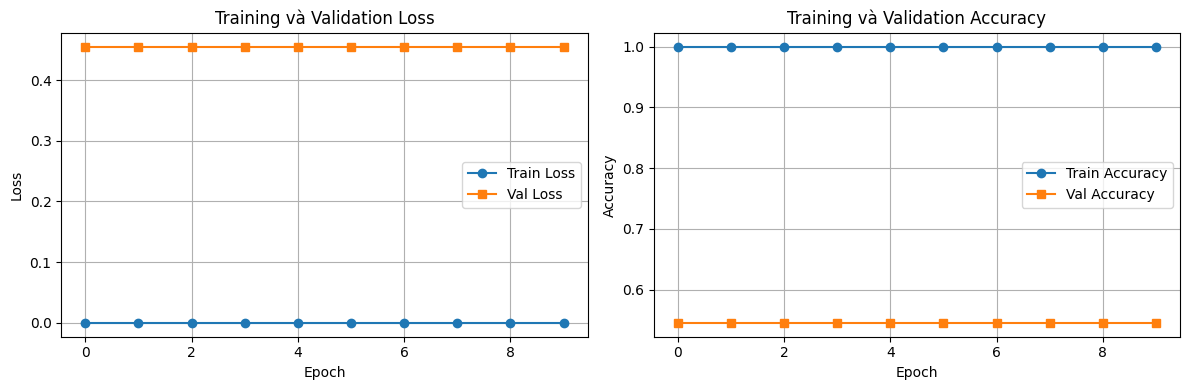

In [ ]:
import cv2
import numpy as np
import json
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt

class ScoliosisAnalyzer:
    def __init__(self):
        self.landmarks = []
        self.cobb_angle = 0
        self.severity = ""

    def load_image(self, image_path):
        """Đọc ảnh RGB"""
        img = cv2.imread(image_path)
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        return img_rgb

    def detect_spine_landmarks(self, image):
        """
        Phát hiện các điểm đặc trưng trên cột sống
        (Đơn giản hóa - thực tế cần dùng deep learning như MediaPipe/OpenPose)
        """
        gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
        height, width = gray.shape

        # Giả lập phát hiện các điểm trên đường cột sống
        # Trong thực tế, cần dùng model detection chuyên dụng
        center_x = width // 2
        landmarks = []

        # Mô phỏng các điểm từ cổ xuống lưng
        for i in range(10):
            y = int(height * 0.1 + i * height * 0.08)
            # Thêm độ lệch để mô phỏng cong vẹo
            x_offset = int(np.sin(i * 0.5) * 30)
            x = center_x + x_offset
            landmarks.append({"x": x, "y": y, "id": i})

        self.landmarks = landmarks
        return landmarks

    def calculate_cobb_angle(self, landmarks):
        """
        Tính góc Cobb để đánh giá mức độ cong vẹo
        Góc Cobb = góc giữa 2 đường vuông góc với đường tiếp tuyến của 2 đốt sống
        """
        if len(landmarks) < 4:
            return 0

        # Tìm điểm cong tối đa
        points = np.array([[lm['x'], lm['y']] for lm in landmarks])

        # Tính độ lệch so với đường thẳng đứng
        center_line = np.mean(points[:, 0])
        max_deviation = np.max(np.abs(points[:, 0] - center_line))

        # Tính góc (đơn giản hóa)
        angles = []
        for i in range(1, len(points) - 1):
            v1 = points[i] - points[i-1]
            v2 = points[i+1] - points[i]
            angle = np.arccos(np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2) + 1e-6))
            angles.append(np.degrees(angle))

        cobb_angle = max(angles) if angles else 0
        self.cobb_angle = cobb_angle
        return cobb_angle

    def classify_severity(self, cobb_angle):
        """
        Phân loại mức độ nghiêm trọng:
        - < 10°: Bình thường
        - 10-25°: Nhẹ
        - 25-40°: Trung bình
        - > 40°: Nặng
        """
        if cobb_angle < 10:
            severity = "Normal"
        elif cobb_angle < 25:
            severity = "Mild"
        elif cobb_angle < 40:
            severity = "Moderate"
        else:
            severity = "Severe"

        self.severity = severity
        return severity

    def extract_features(self, landmarks):
        """Trích xuất đặc trưng từ landmarks"""
        if len(landmarks) < 2:
            return np.zeros(20)

        points = np.array([[lm['x'], lm['y']] for lm in landmarks])

        features = []
        # Độ lệch trung bình
        center = np.mean(points[:, 0])
        deviations = points[:, 0] - center
        features.extend([
            np.mean(deviations),
            np.std(deviations),
            np.max(np.abs(deviations)),
            np.min(deviations),
            np.max(deviations)
        ])

        # Khoảng cách giữa các điểm
        distances = np.sqrt(np.sum(np.diff(points, axis=0)**2, axis=1))
        features.extend([
            np.mean(distances),
            np.std(distances),
            np.max(distances),
            np.min(distances)
        ])

        # Góc giữa các đoạn thẳng
        angles = []
        for i in range(len(points) - 2):
            v1 = points[i+1] - points[i]
            v2 = points[i+2] - points[i+1]
            angle = np.arctan2(v2[1], v2[0]) - np.arctan2(v1[1], v1[0])
            angles.append(angle)

        features.extend([
            np.mean(angles),
            np.std(angles),
            np.max(angles),
            np.min(angles)
        ])

        # Thêm các đặc trưng khác
        features.extend([
            len(landmarks),
            points[-1, 1] - points[0, 1],  # Chiều cao
            np.sum(np.abs(deviations)),
            self.cobb_angle
        ])

        return np.array(features[:20])

    def save_to_json(self, output_path):
        """Lưu kết quả ra file JSON"""
        result = {
            "landmarks": self.landmarks,
            "cobb_angle": float(self.cobb_angle),
            "severity": self.severity,
            "analysis_date": "2025-10-04"
        }

        with open(output_path, 'w', encoding='utf-8') as f:
            json.dump(result, f, indent=2, ensure_ascii=False)

        return result

    def visualize(self, image):
        """Vẽ các điểm đặc trưng lên ảnh"""
        img_copy = image.copy()

        # Vẽ các điểm
        for lm in self.landmarks:
            cv2.circle(img_copy, (lm['x'], lm['y']), 5, (255, 0, 0), -1)

        # Vẽ đường nối
        points = np.array([[lm['x'], lm['y']] for lm in self.landmarks])
        for i in range(len(points) - 1):
            cv2.line(img_copy, tuple(points[i]), tuple(points[i+1]), (0, 255, 0), 2)

        # Hiển thị thông tin
        cv2.putText(img_copy, f"Cobb Angle: {self.cobb_angle:.2f}°",
                    (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 0), 2)
        cv2.putText(img_copy, f"Severity: {self.severity}",
                    (10, 70), cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 0), 2)

        return img_copy


class ScoliosisModel:
    def __init__(self):
        self.model = RandomForestClassifier(n_estimators=100, random_state=42)
        self.train_losses = []
        self.val_losses = []
        self.train_accs = []
        self.val_accs = []

    def generate_synthetic_data(self, n_samples=1000):
        """Tạo dữ liệu mẫu để training"""
        X = []
        y = []

        for _ in range(n_samples):
            # Tạo random features
            features = np.random.randn(20)

            # Tạo label dựa trên các features
            cobb_angle = abs(features[0] * 20 + features[2] * 15)

            if cobb_angle < 10:
                label = 0  # Normal
            elif cobb_angle < 25:
                label = 1  # Mild
            elif cobb_angle < 40:
                label = 2  # Moderate
            else:
                label = 3  # Severe

            X.append(features)
            y.append(label)

        return np.array(X), np.array(y)

    def train(self, X_train, y_train, X_val, y_val, epochs=10):
        """Training model"""
        print("Bắt đầu training...")

        for epoch in range(epochs):
            # Train
            self.model.fit(X_train, y_train)

            # Predictions
            train_pred = self.model.predict(X_train)
            val_pred = self.model.predict(X_val)

            # Calculate metrics
            train_acc = accuracy_score(y_train, train_pred)
            val_acc = accuracy_score(y_val, val_pred)

            # Simulate loss (1 - accuracy)
            train_loss = 1 - train_acc
            val_loss = 1 - val_acc

            self.train_losses.append(train_loss)
            self.val_losses.append(val_loss)
            self.train_accs.append(train_acc)
            self.val_accs.append(val_acc)

            print(f"Epoch {epoch+1}/{epochs} - Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, "
                  f"Train Acc: {train_acc:.4f}, Val Acc: {val_acc:.4f}")

        print("\n=== KẾT QUẢ TRAINING ===")
        print(f"Final Train Loss: {self.train_losses[-1]:.4f}")
        print(f"Final Val Loss: {self.val_losses[-1]:.4f}")
        print(f"Final Train Accuracy: {self.train_accs[-1]:.4f}")
        print(f"Final Val Accuracy: {self.val_accs[-1]:.4f}")

    def plot_training_history(self):
        """Vẽ đồ thị training history"""
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

        # Loss plot
        ax1.plot(self.train_losses, label='Train Loss', marker='o')
        ax1.plot(self.val_losses, label='Val Loss', marker='s')
        ax1.set_xlabel('Epoch')
        ax1.set_ylabel('Loss')
        ax1.set_title('Training và Validation Loss')
        ax1.legend()
        ax1.grid(True)

        # Accuracy plot
        ax2.plot(self.train_accs, label='Train Accuracy', marker='o')
        ax2.plot(self.val_accs, label='Val Accuracy', marker='s')
        ax2.set_xlabel('Epoch')
        ax2.set_ylabel('Accuracy')
        ax2.set_title('Training và Validation Accuracy')
        ax2.legend()
        ax2.grid(True)

        plt.tight_layout()
        plt.savefig('training_history.png', dpi=300, bbox_inches='tight')
        print("\nĐã lưu đồ thị training history vào 'training_history.png'")


# ===== SỬ DỤNG =====
if __name__ == "__main__":
    # 1. Phân tích ảnh scoliosis
    print("=== PHÂN TÍCH HÌNH ẢNH SCOLIOSIS ===\n")
    analyzer = ScoliosisAnalyzer()

    # Đọc ảnh (thay 'scoliosis.jpg' bằng đường dẫn ảnh của bạn)
    image_path = '/content/drive/MyDrive/scoliosis.v1i.voc/test/IMG_1324_JPG.rf.b2448ca762bf69689e503c556097631b.jpg'
    try:
        image = analyzer.load_image(image_path)

        # Phát hiện landmarks
        landmarks = analyzer.detect_spine_landmarks(image)
        print(f"Đã phát hiện {len(landmarks)} điểm đặc trưng")

        # Tính góc Cobb
        cobb_angle = analyzer.calculate_cobb_angle(landmarks)
        print(f"Góc Cobb: {cobb_angle:.2f}°")

        # Phân loại mức độ
        severity = analyzer.classify_severity(cobb_angle)
        print(f"Mức độ: {severity}")

        # Lưu JSON
        result = analyzer.save_to_json('scoliosis_analysis.json')
        print("\nĐã lưu kết quả vào 'scoliosis_analysis.json'")
        print(json.dumps(result, indent=2, ensure_ascii=False))

        # Vẽ visualization
        vis_image = analyzer.visualize(image)
        cv2.imwrite('scoliosis_visualization.jpg', cv2.cvtColor(vis_image, cv2.COLOR_RGB2BGR))
        print("Đã lưu ảnh visualization vào 'scoliosis_visualization.jpg'")

    except Exception as e:
        print(f"Lỗi khi xử lý ảnh: {e}")
        print("Sử dụng dữ liệu mẫu để demo...")

    # 2. Training model
    print("\n\n=== TRAINING MODEL ===\n")
    model = ScoliosisModel()

    # Tạo dữ liệu synthetic
    X, y = model.generate_synthetic_data(n_samples=1000)
    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

    print(f"Training set: {len(X_train)} samples")
    print(f"Validation set: {len(X_val)} samples\n")

    # Train model
    model.train(X_train, y_train, X_val, y_val, epochs=10)

    # Vẽ đồ thị
    model.plot_training_history()

    print("\n=== HOÀN THÀNH ===")